In [3]:
print(sys.executable)

g:\Mi unidad\Tesis v1\mt\Scripts\python.exe


## ENTRENAMIENTO DE MODELOS EN BASE A NUESTRO DATASET PREPROCESADO ANTERIORMENTE
#### Dentro de este jupyter se presenta todo el proceso de entrenamiento de un nuevo modelo en base a los datos que recopilamos y preprocesamos en el notebook anterior. Este notebook presenta todo el proceso de entrenamiento, evaluación y ajuste fino para la clasificación de los paradigmas dentro de una señal EEG
##### Este notebook es una muestra simple de cómo poder usar la librería `Backend_DL`para un pipeline completo de formación de modelos de predicción de paradigmas EEG, con ayuda de ***EEGNET*** y *TensorFLOW* 

##### Los objetivos principales de esta librería son:

- Creación de un objeto para la preselección de los datos 
- Preselección de las clases para entrenar
- Selección de los canales a utilizar
- Creación de npz a formato compatible con entrenamiento de Keras 
- Separación de clases y undersampleo y balance de las mismas 
- Split de los datos de entrenamiento con estratificación en sujetos, sesiones o triales compatibles con el formato [MOABB](https://moabb.neurotechx.com/docs/index.html)
- Normalización de los datos para keras
- Entrenamiento general del modelo con definición de hiperparámetros 
- Aplicación de ajuste fino 
- Evaluación y métricas de los modelos

### 1) Establecer área de trabajo (Pueden ignorar esta primera celda y sólo importar la librería)

In [1]:
import os
import sys
import numpy as np

project_path = 'G:\\Mi unidad\\Tesis v1\\Movement_clasify' 
print(f"Ruta de trabajo actual: {project_path}")



os.chdir(project_path) #change directory B)
sys.path.append(project_path)


#Elegimos la ruta donde trabajaremos con colab
BASE_FOLDER = os.getcwd() #Ruta actual del proyecto

#Rutas donde tenemos demás recursos
scripts_path = os.path.join(BASE_FOLDER, 'scripts')
note_path = os.path.join(BASE_FOLDER, 'notebooks')
resources_path = os.path.join(BASE_FOLDER, 'Recursos')

#Asegurarnos de que todos existan
if os.path.exists(scripts_path): #Donde están nuestras librerían
    if scripts_path not in sys.path:
        sys.path.append(scripts_path)
        print(f"✅ Path agregado: {scripts_path}")
else: print(f"No encontrse encontró la carpeta en {scripts_path}")
if os.path.exists(note_path): #
    if note_path not in sys.path:
        sys.path.append(note_path)
        print(f"✅ Path agregado: {note_path}")
else: print(f"No encontrse encontró la carpeta en {note_path}")
if os.path.exists(resources_path):#Donde están nuestros datos
    if resources_path not in sys.path:
        sys.path.append(resources_path)
        print(f"✅ Path agregado: {resources_path}")
else: print(f"No encontrse encontró la carpeta en {resources_path}")

#Importamos nuestras librerías internas
import backend_DL_v2 as dl

Ruta de trabajo actual: G:\Mi unidad\Tesis v1\Movement_clasify
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\scripts
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\notebooks
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\Recursos


### 2) Creación de objeto y selección de canales, al crear del objeto se pueden especificar: 
- La selección de canales
- La posibilidad de undersamplear las clases mayoritarias por balance 
- Posibilidad de fusionar o no las clases imaginarias con las motoras

En el caso de este dataset, la distribución de clases quedaría de la siguiente manera: 
    "rest" -> 0

    "right_i" -> 1

    "left_i"->2

    "hands_i" -> 3

    "feet_i" -> 4

    "right_m" -> 5

    "left_m" -> 6

    "hands_m" -> 7
    
    "feet_m" -> 8

In [2]:


"""            
            0: FULL           
            1: SOLO MOTOR (5 clases)
            2: SOLO IMAGINADO 5 CLASES
            3: 9 CLASES SIN FUSIÓN
            4: REST-IZQ-DER fusionado
            5: REST-MANOS-PIES fusionado
            6: REST-IZQ-DER SOLO MOTOR
            7: REST-MANOS-PIES SOLO MOTOR
            8: TODAS CLASES BINARIO (REST vs MOVIMIENTO)
            9: REST vs MOVIMIENTO SOLO MOTOR
            10: MANOS VS PIES, fusionado
            11: MANOS VS PIES, solo motor
            12: DERECHA vs IZQUIERDA, fusionado 
            13: DERECHA vs IZQUIERDA, solo motor
            14: IZQ-DER-MANO-PIES FUSIONADAS
            15: IZQ-DER-MANO-PIES SOLO MOTOR
"""

#Probamos nuestro nuevo objeto
pick = 6
obj = dl.Selection(pick=pick, Debug=False)



### 3) Una vez creado el objeto, se puede establecer una ruta al dataset para ejecutar y a su vez se pueden elegir los canales que se quieren usar para el entrenamiento con el atributo "pick_ch"
(Recordatorio: debo crear una función de fet channels, pues ya existe el resume_dataset pero para evitar tantos datos)

In [3]:
path_dataset = "Recursos/3_ch/101_subs/eeg_dataset_0.00015rate.npz"
obj.load(path_dataset)
#obj.pick_ch(["C3..", "C4..", "Cz.."])
print("y antes del pipeline:", np.unique(obj.y, return_counts=True))
#obj.resume_dataset(subs=True)


✔️ Dataset cargado desde: Recursos/3_ch/101_subs/eeg_dataset_0.00015rate.npz
y antes del pipeline: (array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32), array([86250, 10800, 10990, 10870, 10890, 10855, 10915, 10735, 10955]))


### 4) Una vez todos los argumentos listos, se puede usar el atributo "pipeline" para ejecutar todo lo pedido

In [4]:
obj.pipeline(undersample_rest=True)

# Debug inmediato
print("y único:", np.unique(obj.y))
print("conteos:", np.unique(obj.y, return_counts=True))
print("X shape:", obj.X.shape)



Undersampling: clase 0 recortada de 86250 a 10915 muestras.
y único: [0 1 2]
conteos: (array([0, 1, 2], dtype=int32), array([10915, 10855, 10915]))
X shape: (32685, 3, 160)


### 4.5) Opcionalmente, se puede usar el atributo "resume_data" para examinar los datos antes del entrenamiento

In [5]:
obj.resume_data()



X shape: (32685, 3, 160)
y shape: (32685,)
sub shape: (32685,)
trial shape: (32685,)
run shape: (32685,)
Número de clases: 3
Número de sujetos: 97

Clases:
   codigo   nombre
0       0     rest
1       1  right_m
2       2   left_m

Conteo por clase:
0    10915
1    10855
2    10915
Name: count, dtype: int64


### 5) Con el método "pick_fine" se pueden separtar los datos en aquellos datos de entrenamiento y aquellos datos de ajuste fino 
(Recordatorio: debo hacer un atributo de get_model para aquellos que no quieran dividir el dataset)

In [6]:
data_model, data_fine = obj.pick_fine(7)

print("Distribución de clases en data_model:", np.unique(data_model.y, return_counts=True))
print("Distribución de clases en data_fine:", np.unique(data_fine.y, return_counts=True))

Distribución de clases en data_model: (array([0, 1, 2], dtype=int32), array([10790, 10745, 10800]))
Distribución de clases en data_fine: (array([0, 1, 2], dtype=int32), array([125, 110, 115]))


### 6) Entrenamiento del modelo general con "eeg_train", se establecen las épocas, el modo de estratificación, así como el tamaño de la separación de los datos de entrenamiento y validación

In [7]:
modelo, history, mean, std, keras_split, info = dl.eeg_train(
    data_model, test_size=0.15, val_size=0.15, 
    mode="subject",
    epochs=60,
    debug=False
)

c:\Users\Josjuan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test loss=1.0522, acc=0.4181


##### Examinar modelo obtenido

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=== Evaluación EEGNet ===
Clases (índice -> nombre):
  0: rest
  1: right_m
  2: left_m

Matriz de confusión (conteos):
[[650 614 435]
 [263 962 445]
 [238 949 503]]

Reporte de clasificación:
              precision    recall  f1-score   support

        rest       0.56      0.38      0.46      1699
     right_m       0.38      0.58      0.46      1670
      left_m       0.36      0.30      0.33      1690

    accuracy                           0.42      5059
   macro avg       0.44      0.42      0.41      5059
weighted avg       0.44      0.42      0.41      5059



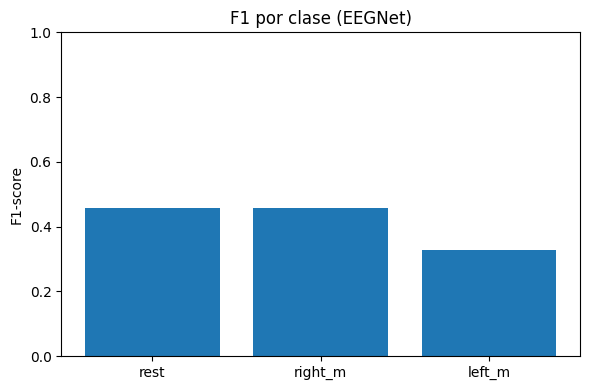

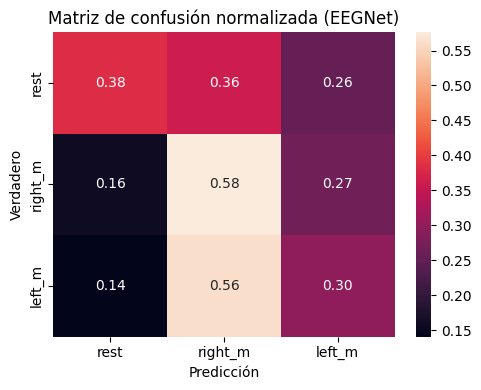

{'y_pred': array([2, 1, 1, ..., 2, 2, 2], shape=(5059,)),
 'cm': array([[650, 614, 435],
        [263, 962, 445],
        [238, 949, 503]]),
 'cm_norm': array([[0.38257799, 0.36138905, 0.25603296],
        [0.15748503, 0.5760479 , 0.26646707],
        [0.1408284 , 0.56153846, 0.29763314]]),
 'precision': array([0.56472632, 0.3809901 , 0.3637021 ]),
 'recall': array([0.38257799, 0.5760479 , 0.29763314]),
 'f1': array([0.45614035, 0.45864124, 0.32736739])}

In [8]:
dl.evaluate(modelo, keras_split, obj.label_map)

In [9]:
#Guardamos el modelo y sus parámetros de normalización
clases = np.unique(obj.pick)
path = f"Recursos/models/general/v2/{pick}_mode_trained_models_v1"

if not os.path.exists(path):
    os.makedirs(path)

dl.save_model(
    model=modelo,
    mean=mean,
    std=std,
    label_map=obj.label_map,
    path=path,
    name="EEGNet_LR3_v1"
)



Modelo guardado: Recursos/models/general/v2/6_mode_trained_models_v1\EEGNet_LR3_v1.keras
Parámetros guardados: Recursos/models/general/v2/6_mode_trained_models_v1\EEGNet_LR3_v1.npz
Clases del modelo: {0: np.str_('rest'), 1: np.str_('right_m'), 2: np.str_('left_m')}


In [10]:
#Cargar modelo en caso de que ya tenegamos uno guardado
#modelo, mean, std = dl.load_model(model_path = "Recursos/models/general/97_subjects/[None]_trained_models_v1/Gmodel_166170_97.keras", 
#                                  params_path = "Recursos/models/general/97_subjects/[None]_trained_models_v1/EEGnet_general_166170_97.npz")


In [11]:
modelo_ft, histor_ft, mean_ft, std_ft, keras_split_ft = dl.eeg_fine(modelo, data_fine, mean = mean, std = std, test_size=0.15, val_size=0.15,
                                                        debug=False, epochs=150, lr=2e-4, batch_size=16, unfreeze_last_n=None, normalize=False)


[Fine-tune] Test loss=0.8646, acc=0.6226


Distribución de train (array([0, 1, 2], dtype=int32), array([88, 80, 75]))
Distribución de validation (array([0, 1, 2], dtype=int32), array([19, 10, 25]))
Distribución de test (array([0, 1, 2], dtype=int32), array([18, 20, 15]))
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

=== Evaluación EEGNet ===
Clases (índice -> nombre):
  0: rest
  1: right_m
  2: left_m

Matriz de confusión (conteos):
[[74 22 29]
 [ 7 72 31]
 [ 2 18 95]]

Reporte de clasificación:
              precision    recall  f1-score   support

        rest       0.89      0.59      0.71       125
     right_m       0.64      0.65      0.65       110
      left_m       0.61      0.83      0.70       115

    accuracy                           0.69       350
   macro avg       0.72      0.69      0.69       350
weighted avg       0.72      0.69      0.69       350



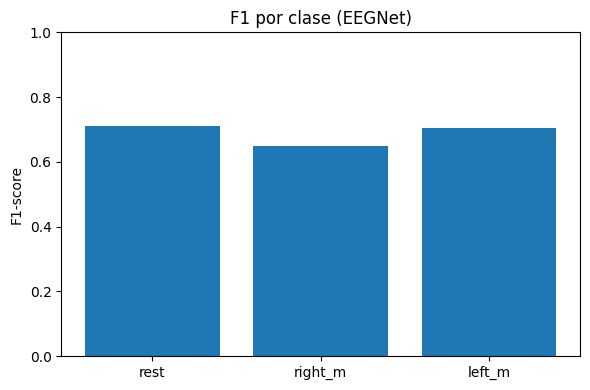

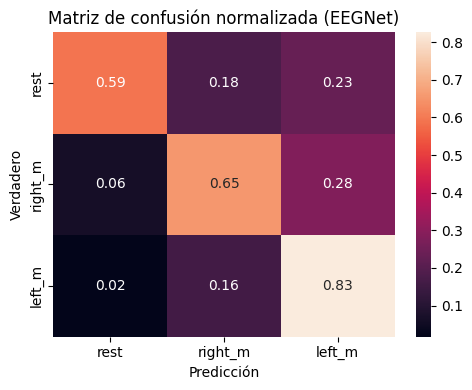

{'y_pred': array([2, 2, 0, 2, 2, 1, 0, 2, 1, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 1, 2, 0,
        1, 1, 2, 0, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 0, 0, 2, 1, 2, 1, 2,
        1, 1, 0, 2, 2, 2, 2, 1, 2, 2, 0, 0, 1, 2, 1, 1, 1, 2, 2, 2, 0, 1,
        2, 1, 0, 2, 1, 1, 0, 0, 1, 2, 2, 0, 0, 2, 1, 1, 2, 1, 1, 2, 0, 1,
        2, 0, 2, 0, 1, 1, 0, 2, 0, 1, 1, 0, 2, 2, 2, 1, 0, 2, 2, 1, 0, 0,
        1, 0, 2, 0, 0, 2, 0, 1, 2, 0, 1, 2, 1, 2, 2, 2, 0, 0, 1, 2, 0, 1,
        1, 2, 1, 0, 0, 2, 2, 1, 2, 0, 1, 2, 2, 2, 1, 2, 1, 0, 2, 2, 2, 1,
        2, 0, 2, 2, 1, 1, 1, 2, 2, 1, 2, 2, 0, 2, 0, 1, 0, 1, 2, 1, 2, 1,
        2, 2, 0, 0, 0, 0, 2, 1, 2, 0, 1, 1, 1, 2, 0, 2, 2, 1, 2, 2, 2, 1,
        2, 0, 0, 2, 0, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 0, 2, 1, 1, 2, 1,
        1, 0, 1, 1, 2, 0, 0, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, 0, 0,
        2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 0, 0, 1, 2, 1, 0, 2, 2, 0, 0, 2, 2,
        0, 2, 2, 1, 0, 2, 0, 2, 2, 2, 1, 2, 2, 1, 1, 2, 2, 1, 0, 2, 0, 1,
        2, 2, 2, 2, 1, 1, 2,

In [12]:
print("Distribución de train", np.unique(keras_split_ft.y.train, return_counts=True))
print("Distribución de validation", np.unique(keras_split_ft.y.val, return_counts=True))
print("Distribución de test", np.unique(keras_split_ft.y.test, return_counts=True))
dl.evaluate(modelo_ft, keras_split_ft, obj.label_map, all_data=True)

In [13]:

path_f = f"Recursos/models/fined/v2/{pick}_mode_finned_model_v1"
print(f"Guardando modelo en: {path_f}")

if not os.path.exists(path_f):
    os.makedirs(path_f)

dl.save_model(
    model=modelo_ft,
    mean=mean_ft,
    std=std_ft,
    label_map=obj.label_map,
    path=path_f,
    name="EEGNet_LR3_subject07_ft_v1"
)


Guardando modelo en: Recursos/models/fined/v2/6_mode_finned_model_v1
Modelo guardado: Recursos/models/fined/v2/6_mode_finned_model_v1\EEGNet_LR3_subject07_ft_v1.keras
Parámetros guardados: Recursos/models/fined/v2/6_mode_finned_model_v1\EEGNet_LR3_subject07_ft_v1.npz
Clases del modelo: {0: np.str_('rest'), 1: np.str_('right_m'), 2: np.str_('left_m')}


In [14]:
#Cargar modelo genersal y modelo fino
modelo, _ , _ = dl.load_model(model_path = "Recursos/models/general/97_subjects/[0 7 8]_trained_models_v1/Gmodel_31345_97_3ch_7.keras", 
                                  params_path = "Recursos/models/general/97_subjects/[None]_trained_models_v1/EEGnet_general_166170_97.npz")

modelo_ft, _ , _ = dl.load_model(model_path = "Recursos/models/fined/97_subjects/[0 7 8]_finned_model_v1/Fmodel_31345_97_3ch_7.keras", 
                                  params_path = "Recursos/models/fined/97_subjects/[0 7 8]_finned_model_v1/EEGnet_fined_31345_97_3ch_7.npz")

split, _ = dl.split_eeg(data_model.X, data_model.y, data_model.sub, data_model.trial, data_model.run, mode = "subject", test_size=0.15, val_size=0.15)
split_ft, _ = dl.split_eeg(data_fine.X, data_fine.y, data_fine.sub, data_fine.trial, data_fine.run, mode = "trial", test_size=0.15, val_size=0.15)

norm_split, channel_mean, channel_std = dl.normalizar_split(split)
norm_split_ft, _, _ = dl.normalizar_split(split_ft)

keras_split = dl.prepare_keras_split(norm_split)
keras_split_ft = dl.prepare_keras_split(norm_split_ft)


In [15]:
metrics = dl.compare_models(modelo, modelo_ft ,keras_split, keras_split_ft, obj.label_map)


 COMPARACIÓN MODELO GENERAL vs FINE-TUNING 

[ MODELO GENERAL ]
Accuracy : 0.3651
Macro F1 : 0.3219

[ FINE-TUNING ]
Accuracy : 0.3962
Macro F1 : 0.2615

[ MEJORAS ]
Δ Accuracy absoluta : +3.11 puntos
Δ Accuracy relativa : +8.53%
Δ Macro F1 absoluta : +-6.04 puntos
Δ Macro F1 relativa : +-18.76%


=== Classification Report (General) ===

              precision    recall  f1-score   support

        rest       0.36      0.73      0.49      1699
     right_m       0.35      0.21      0.27      1670
      left_m       0.40      0.15      0.21      1690

    accuracy                           0.37      5059
   macro avg       0.37      0.36      0.32      5059
weighted avg       0.37      0.37      0.32      5059


=== Classification Report (Fine-Tuning) ===

              precision    recall  f1-score   support

        rest       0.38      1.00      0.55        18
     right_m       0.50      0.15      0.23        20
      left_m       0.00      0.00      0.00        15

    accuracy  